# Vérifier les données Silver avant de définir le Gold

## Objectif concret

Ce notebook explore les incidents, les maintenances, la télémétrie et les commentaires déjà présents dans Silver. Il sert à collecter des éléments factuels avant de décider ce que signifie **un arrêt machine** pour le dataset Gold.

**Point de départ observable :** PostgreSQL contient une couche Silver publiée. Toutes les requêtes de ce notebook sont des `SELECT` : elles lisent les données sans les modifier. Aucun résultat ne vaut encore une décision métier.

In [1]:
from pathlib import Path
import os
import re
import unicodedata

import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chi2_contingency
from sqlalchemy import text
from tabulate import tabulate

from indusense.db.engine import create_database_engine

PROJECT_ROOT = Path.cwd()
assert (PROJECT_ROOT / 'pyproject.toml').exists(), (
    'Ouvrir ce notebook depuis la racine du projet indusense.'
)

# Les paramètres sont chargés sans jamais afficher leurs valeurs sensibles.
for raw_line in (PROJECT_ROOT / '.docker' / '.env').read_text(encoding='utf-8').splitlines():
    line = raw_line.strip()
    if line and not line.startswith('#') and '=' in line:
        key, value = line.split('=', 1)
        os.environ.setdefault(key.strip(), value.strip())

engine = create_database_engine()

def read_sql(query: str) -> pd.DataFrame:
    """Exécute une requête de lecture et renvoie un tableau pandas."""
    with engine.connect() as connection:
        return pd.read_sql(text(query), connection)

def print_table(frame: pd.DataFrame, title: str) -> None:
    print(f'\n{title}')
    print(tabulate(frame, headers='keys', tablefmt='github', showindex=False))


## 1. Vérifier le périmètre réellement analysé

Le **grain** indique ce qu'une ligne représente. Avant de comparer des événements, nous vérifions les volumes de chaque table et les périodes couvertes. Cela évite de tirer une conclusion à partir d'une table vide ou d'un historique incomplet.

In [2]:
coverage = read_sql(
    """
    SELECT 'incident' AS table_name, COUNT(*) AS row_count,
           MIN(occurred_at) AS first_at, MAX(occurred_at) AS last_at
    FROM silver.incident
    UNION ALL
    SELECT 'maintenance', COUNT(*), MIN(maintenance_at), MAX(maintenance_at)
    FROM silver.maintenance
    UNION ALL
    SELECT 'telemetry', COUNT(*), MIN(measured_at), MAX(measured_at)
    FROM silver.telemetry
    """
)
print_table(coverage, 'Périmètre Silver')
assert set(coverage['table_name']) == {'incident', 'maintenance', 'telemetry'}



Périmètre Silver
| table_name   |   row_count | first_at                  | last_at                   |
|--------------|-------------|---------------------------|---------------------------|
| incident     |        1245 | 2025-06-01 05:42:00+00:00 | 2026-06-08 00:29:00+00:00 |
| maintenance  |        1562 | 2025-06-02 04:42:00+00:00 | 2026-06-09 02:29:00+00:00 |
| telemetry    |      134280 | 2025-06-01 00:00:00+00:00 | 2026-06-08 23:00:00+00:00 |


## 2. Décrire les incidents et leur criticité

La **criticité** (`severity`) mesure la gravité déclarée d'un incident. Elle ne prouve pas, à elle seule, un arrêt. Nous comptons donc séparément la criticité et les neuf types structurés d'incident, dont `is_emergency_stop`.


Incidents par criticité
|   severity |   incident_count |   emergency_stop_count |   emergency_stop_pct |
|------------|------------------|------------------------|----------------------|
|          2 |              336 |                      2 |                 0.6  |
|          3 |              704 |                      2 |                 0.28 |
|          4 |              167 |                     14 |                 8.38 |
|          5 |               38 |                      1 |                 2.63 |

Types structurés d’incident
| incident_type       |   incident_count |
|---------------------|------------------|
| sensor_alarm        |              215 |
| mechanical_noise    |              207 |
| quality_defect      |              181 |
| vibration           |              179 |
| pressure_drop       |              168 |
| overconsumption     |              149 |
| overheating         |              134 |
| emergency_stop      |               19 |
| mechanical_blockage | 

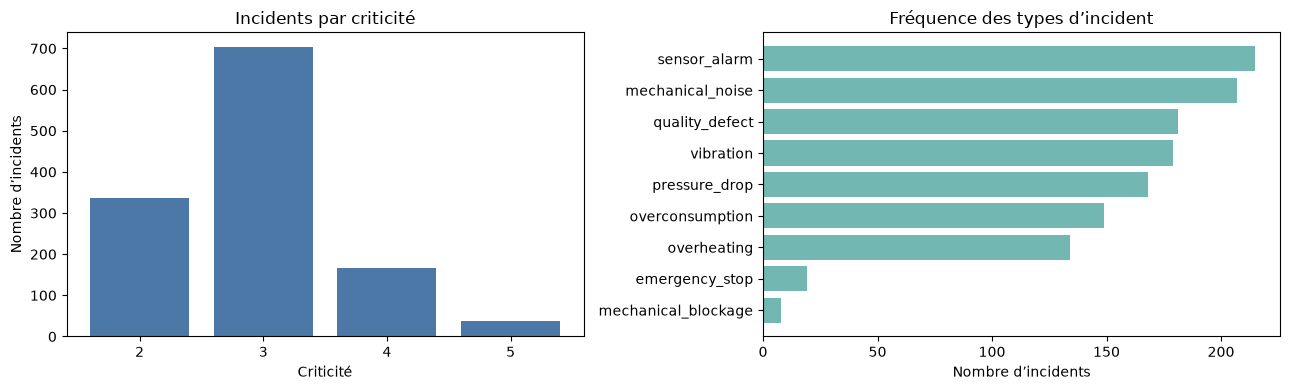

In [3]:
severity = read_sql(
    """
    SELECT severity, COUNT(*) AS incident_count,
           SUM(is_emergency_stop::int) AS emergency_stop_count,
           ROUND(100.0 * AVG(is_emergency_stop::int), 2) AS emergency_stop_pct
    FROM silver.incident
    GROUP BY severity
    ORDER BY severity
    """
)
incident_types = read_sql(
    """
    SELECT * FROM (
        SELECT 'overheating' AS incident_type, SUM(is_overheating::int) AS incident_count FROM silver.incident
        UNION ALL SELECT 'pressure_drop', SUM(is_pressure_drop::int) FROM silver.incident
        UNION ALL SELECT 'vibration', SUM(is_vibration::int) FROM silver.incident
        UNION ALL SELECT 'mechanical_noise', SUM(is_mechanical_noise::int) FROM silver.incident
        UNION ALL SELECT 'overconsumption', SUM(is_overconsumption::int) FROM silver.incident
        UNION ALL SELECT 'mechanical_blockage', SUM(is_mechanical_blockage::int) FROM silver.incident
        UNION ALL SELECT 'sensor_alarm', SUM(is_sensor_alarm::int) FROM silver.incident
        UNION ALL SELECT 'emergency_stop', SUM(is_emergency_stop::int) FROM silver.incident
        UNION ALL SELECT 'quality_defect', SUM(is_quality_defect::int) FROM silver.incident
    ) AS counts
    ORDER BY incident_count DESC, incident_type
    """
)
print_table(severity, 'Incidents par criticité')
print_table(incident_types, 'Types structurés d’incident')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(severity['severity'].astype(str), severity['incident_count'], color='#4C78A8')
axes[0].set(title='Incidents par criticité', xlabel='Criticité', ylabel='Nombre d’incidents')
axes[1].barh(incident_types['incident_type'], incident_types['incident_count'], color='#72B7B2')
axes[1].set(title='Fréquence des types d’incident', xlabel='Nombre d’incidents')
axes[1].invert_yaxis()
fig.tight_layout()
plt.show()


## 3. Examiner les arrêts d'urgence sans les confondre avec les autres incidents

Un **arrêt d'urgence** est ici un indicateur booléen : `true` ou `false`. Nous regardons avec quels autres types il coexiste. Cela renseigne sur son contexte, mais ne démontre ni une cause ni une définition métier définitive de l'arrêt machine.


Types présents avec un arrêt d’urgence
| cooccurring_type    |   stop_incident_count |
|---------------------|-----------------------|
| overheating         |                     6 |
| pressure_drop       |                     3 |
| sensor_alarm        |                     3 |
| mechanical_noise    |                     1 |
| quality_defect      |                     1 |
| vibration           |                     1 |
| mechanical_blockage |                     0 |
| overconsumption     |                     0 |

Incidents et arrêts d’urgence par machine
| machine_code   |   incident_count |   emergency_stop_count |
|----------------|------------------|------------------------|
| MACH-05        |               70 |                      6 |
| MACH-04        |               41 |                      2 |
| MACH-10        |               78 |                      2 |
| MACH-12        |               57 |                      2 |
| MACH-15        |               63 |                      

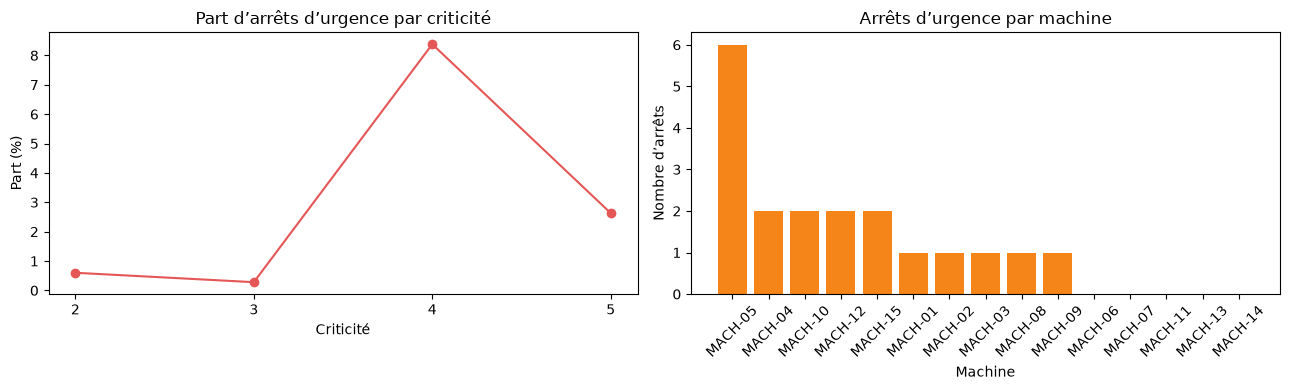

In [4]:
stop_context = read_sql(
    """
    SELECT * FROM (
        SELECT 'overheating' AS cooccurring_type, SUM(is_overheating::int) AS stop_incident_count FROM silver.incident WHERE is_emergency_stop
        UNION ALL SELECT 'pressure_drop', SUM(is_pressure_drop::int) FROM silver.incident WHERE is_emergency_stop
        UNION ALL SELECT 'vibration', SUM(is_vibration::int) FROM silver.incident WHERE is_emergency_stop
        UNION ALL SELECT 'mechanical_noise', SUM(is_mechanical_noise::int) FROM silver.incident WHERE is_emergency_stop
        UNION ALL SELECT 'overconsumption', SUM(is_overconsumption::int) FROM silver.incident WHERE is_emergency_stop
        UNION ALL SELECT 'mechanical_blockage', SUM(is_mechanical_blockage::int) FROM silver.incident WHERE is_emergency_stop
        UNION ALL SELECT 'sensor_alarm', SUM(is_sensor_alarm::int) FROM silver.incident WHERE is_emergency_stop
        UNION ALL SELECT 'quality_defect', SUM(is_quality_defect::int) FROM silver.incident WHERE is_emergency_stop
    ) AS counts
    ORDER BY stop_incident_count DESC, cooccurring_type
    """
)
by_machine = read_sql(
    """
    SELECT machine_code, COUNT(*) AS incident_count,
           SUM(is_emergency_stop::int) AS emergency_stop_count
    FROM silver.incident
    GROUP BY machine_code
    ORDER BY emergency_stop_count DESC, machine_code
    """
)
print_table(stop_context, 'Types présents avec un arrêt d’urgence')
print_table(by_machine, 'Incidents et arrêts d’urgence par machine')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(severity['severity'], severity['emergency_stop_pct'], marker='o', color='#E45756')
axes[0].set(title='Part d’arrêts d’urgence par criticité', xlabel='Criticité', ylabel='Part (%)', xticks=severity['severity'])
axes[1].bar(by_machine['machine_code'], by_machine['emergency_stop_count'], color='#F58518')
axes[1].set(title='Arrêts d’urgence par machine', xlabel='Machine', ylabel='Nombre d’arrêts')
axes[1].tick_params(axis='x', rotation=45)
fig.tight_layout()
plt.show()


## 4. Relier les maintenances aux incidents

Une maintenance est **réactive** lorsqu'elle référence un incident ; elle est **proactive** lorsqu'elle est planifiée sans incident lié. Nous comparons leurs volumes, durées et liens aux incidents d'arrêt. Une maintenance qui suit un incident n'est pas automatiquement la preuve que la machine était arrêtée.


Maintenances par type
| maintenance_type   |   maintenance_count |   mean_duration_hours |   max_duration_hours |
|--------------------|---------------------|-----------------------|----------------------|
| proactive          |                  90 |                  2.34 |                 3.49 |
| reactive           |                1472 |                  2.49 |                 8    |

Maintenances réactives liées aux incidents
| is_emergency_stop   |   reactive_maintenance_count |   mean_delay_hours |
|---------------------|------------------------------|--------------------|
| True                |                           25 |             347.71 |
| False               |                         1447 |             521.44 |


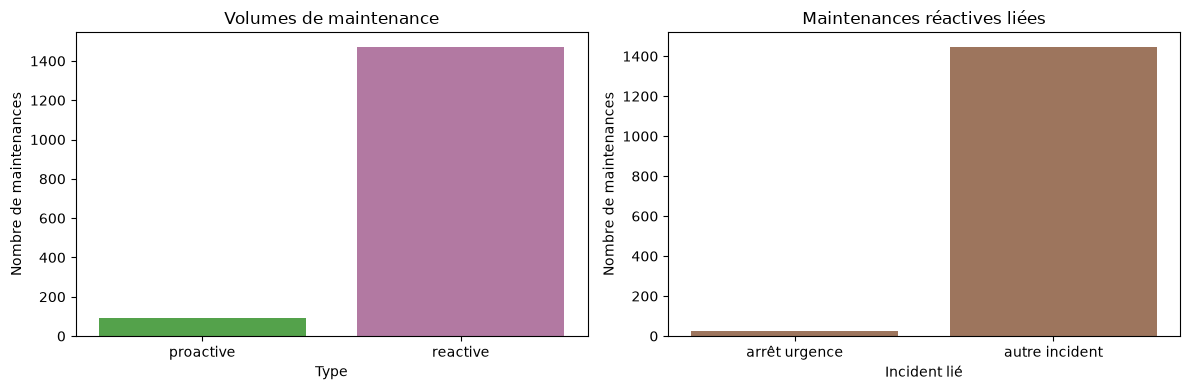

In [5]:
maintenance_summary = read_sql(
    """
    SELECT maintenance_type, COUNT(*) AS maintenance_count,
           ROUND(AVG(duration_hours)::numeric, 2) AS mean_duration_hours,
           ROUND(MAX(duration_hours)::numeric, 2) AS max_duration_hours
    FROM silver.maintenance
    GROUP BY maintenance_type
    ORDER BY maintenance_type
    """
)
reactive_links = read_sql(
    """
    SELECT i.is_emergency_stop, COUNT(m.maintenance_id) AS reactive_maintenance_count,
           ROUND(AVG(EXTRACT(EPOCH FROM (m.maintenance_at - i.occurred_at)) / 3600.0)::numeric, 2) AS mean_delay_hours
    FROM silver.incident AS i
    LEFT JOIN silver.maintenance AS m
      ON m.related_incident_id = i.incident_id
     AND m.machine_code = i.machine_code
     AND m.maintenance_type = 'reactive'
    GROUP BY i.is_emergency_stop
    ORDER BY i.is_emergency_stop DESC
    """
)
print_table(maintenance_summary, 'Maintenances par type')
print_table(reactive_links, 'Maintenances réactives liées aux incidents')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(maintenance_summary['maintenance_type'], maintenance_summary['maintenance_count'], color=['#54A24B', '#B279A2'])
axes[0].set(title='Volumes de maintenance', xlabel='Type', ylabel='Nombre de maintenances')
axes[1].bar(reactive_links['is_emergency_stop'].map({True: 'arrêt urgence', False: 'autre incident'}), reactive_links['reactive_maintenance_count'], color='#9D755D')
axes[1].set(title='Maintenances réactives liées', xlabel='Incident lié', ylabel='Nombre de maintenances')
fig.tight_layout()
plt.show()


## 5. Étudier les commentaires avec SciPy

Les commentaires sont du texte libre. Pour les examiner sans les transformer en preuve, nous créons deux indicateurs reproductibles : présence des mots `arrêt`/`arret` et `stop`. Un **test du chi-deux** de SciPy compare des effectifs observés à ceux attendus si deux variables étaient indépendantes. Une petite *p-value* indique une association statistique dans cet historique ; elle ne prouve pas une relation de cause à effet et ne garantit pas que le texte était disponible avant l'incident.


Commentaires : mention d’arrêt/stop et contexte d’incident
| mentions_stop   |   incidents |   mean_length |   median_severity |   emergency_stops |   emergency_stop_pct |
|-----------------|-------------|---------------|-------------------|-------------------|----------------------|
| False           |        1227 |          24.8 |                 3 |                 1 |                 0.08 |
| True            |          18 |          34   |                 4 |                18 |               100    |

Test du chi-deux : mention d’arrêt/stop et arrêt d’urgence
|    chi2 |   degrees_of_freedom |   p_value |
|---------|----------------------|-----------|
| 1112.96 |                    1 |         0 |


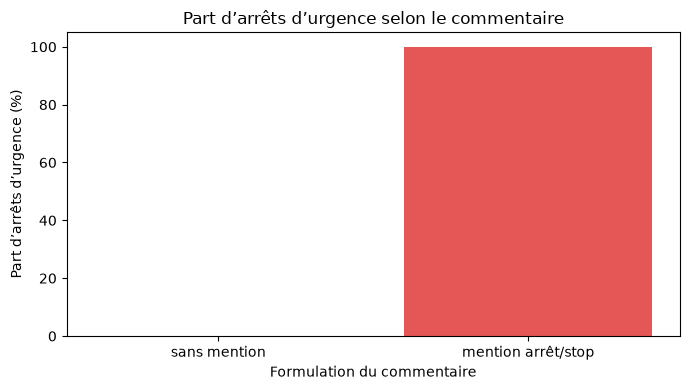

Interprétation : association statistique uniquement ; aucune causalité ni disponibilité temporelle n’est démontrée.


In [6]:
comments = read_sql(
    """
    SELECT incident_id, severity, is_emergency_stop, comment
    FROM silver.incident
    """
)

def normalize_text(value: str) -> str:
    decomposed = unicodedata.normalize('NFKD', value.lower())
    return ''.join(char for char in decomposed if not unicodedata.combining(char))

comments['normalized_comment'] = comments['comment'].map(normalize_text)
comments['mentions_stop'] = comments['normalized_comment'].str.contains(r'\b(?:arret|stop)\b', regex=True)
comments['comment_length'] = comments['comment'].str.len()

comment_summary = comments.groupby('mentions_stop', as_index=False).agg(
    incidents=('incident_id', 'count'),
    mean_length=('comment_length', 'mean'),
    median_severity=('severity', 'median'),
    emergency_stops=('is_emergency_stop', 'sum'),
)
comment_summary['emergency_stop_pct'] = (
    100 * comment_summary['emergency_stops'] / comment_summary['incidents']
).round(2)
comment_summary['mean_length'] = comment_summary['mean_length'].round(1)

contingency = pd.crosstab(comments['mentions_stop'], comments['is_emergency_stop'])
assert contingency.shape == (2, 2), 'Les deux groupes de commentaires doivent être présents.'
chi2, p_value, degrees_of_freedom, expected = chi2_contingency(contingency)
test_result = pd.DataFrame([[chi2, degrees_of_freedom, p_value]], columns=['chi2', 'degrees_of_freedom', 'p_value'])

print_table(comment_summary, 'Commentaires : mention d’arrêt/stop et contexte d’incident')
print_table(test_result.round(6), 'Test du chi-deux : mention d’arrêt/stop et arrêt d’urgence')

plot_comments = comment_summary.copy()
plot_comments['group'] = plot_comments['mentions_stop'].map({True: 'mention arrêt/stop', False: 'sans mention'})
plt.figure(figsize=(7, 4))
plt.bar(plot_comments['group'], plot_comments['emergency_stop_pct'], color=['#BAB0AC', '#E45756'])
plt.title('Part d’arrêts d’urgence selon le commentaire')
plt.xlabel('Formulation du commentaire')
plt.ylabel('Part d’arrêts d’urgence (%)')
plt.tight_layout()
plt.show()
print('Interprétation : association statistique uniquement ; aucune causalité ni disponibilité temporelle n’est démontrée.')


## 6. Contrôler la télémétrie et la production nulle

Une production nulle peut correspondre à un arrêt, mais aussi à une pause planifiée ou à un problème de collecte. Nous la quantifions donc, sans en faire un label. Les mesures manquantes sont également comptées : elles pourront devenir des indicateurs de qualité dans Gold, jamais des zéros inventés.


Qualité et production nulle dans la télémétrie
|   telemetry_count |   zero_production_count |   zero_production_pct |   missing_temperature |   missing_pressure |   missing_rotation |
|-------------------|-------------------------|-----------------------|-----------------------|--------------------|--------------------|
|            134280 |                     270 |                   0.2 |                   882 |                981 |                948 |

Production nulle par machine
| machine_code   |   telemetry_count |   zero_production_count |
|----------------|-------------------|-------------------------|
| MACH-13        |              8952 |                      59 |
| MACH-01        |              8952 |                      44 |
| MACH-03        |              8952 |                      31 |
| MACH-09        |              8952 |                      27 |
| MACH-11        |              8952 |                      14 |
| MACH-02        |              8952 |               

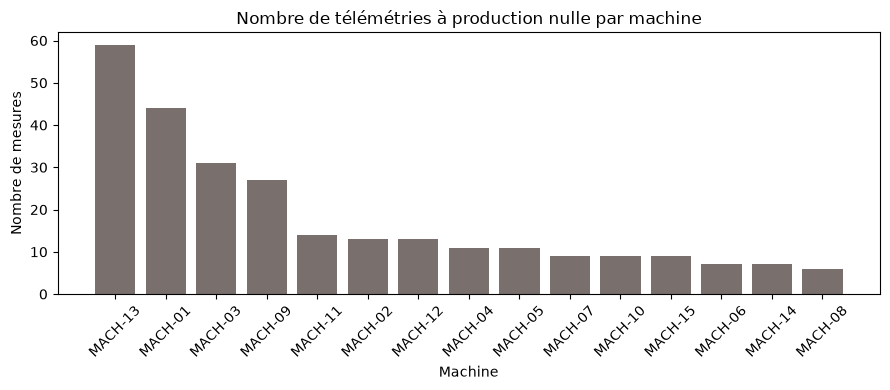

In [7]:
telemetry_quality = read_sql(
    """
    SELECT COUNT(*) AS telemetry_count,
           SUM((pieces_produced = 0)::int) AS zero_production_count,
           ROUND(100.0 * AVG((pieces_produced = 0)::int), 2) AS zero_production_pct,
           SUM((temperature_c IS NULL)::int) AS missing_temperature,
           SUM((pressure_bar IS NULL)::int) AS missing_pressure,
           SUM((rotation_mean_rpm IS NULL)::int) AS missing_rotation
    FROM silver.telemetry
    """
)
zero_by_machine = read_sql(
    """
    SELECT machine_code, COUNT(*) AS telemetry_count,
           SUM((pieces_produced = 0)::int) AS zero_production_count
    FROM silver.telemetry
    GROUP BY machine_code
    ORDER BY zero_production_count DESC, machine_code
    """
)
print_table(telemetry_quality, 'Qualité et production nulle dans la télémétrie')
print_table(zero_by_machine, 'Production nulle par machine')

plt.figure(figsize=(9, 4))
plt.bar(zero_by_machine['machine_code'], zero_by_machine['zero_production_count'], color='#79706E')
plt.title('Nombre de télémétries à production nulle par machine')
plt.xlabel('Machine')
plt.ylabel('Nombre de mesures')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 7. Synthèse avant décision métier

Ce notebook produit des **faits observés**. La prochaine discussion devra distinguer :

1. ce qui est structuré et fiable pour une première définition de label ;
2. ce qui apporte seulement du contexte ;
3. ce qui ne peut pas être utilisé en prédiction, notamment si sa date de disponibilité est inconnue.

La décision finale sur `machine_stop` reste à prendre avec le métier.